# Conflict Serializability Checker

Determines whether a transaction schedule is **conflict serializable** by
building a **precedence (serialization) graph** and checking it for cycles.

**Rule:** two operations *conflict* if they (1) belong to different
transactions, (2) access the same data item, and (3) at least one of them is
a write. For each conflicting pair `op1` (from `Ti`) occurring before `op2`
(from `Tj`) in the schedule, we add an edge `Ti -> Tj`.

The schedule is conflict serializable **iff the precedence graph is acyclic**.
If acyclic, any topological sort gives an equivalent serial order.

Run the setup cells once, then call `analyze_schedule("...")` with any
schedule string — it runs all 5 steps (table, edges, graph, verdict) and
prints/plots them together as one combined output.

## Setup

In [1]:
import re
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Core logic

Parsing, precedence-graph construction, and cycle detection.

In [2]:
class Operation:
    """A single read/write operation in a schedule."""
    __slots__ = ("op_type", "txn", "item", "index")

    def __init__(self, op_type, txn, item, index):
        self.op_type = op_type  # 'R' or 'W'
        self.txn = txn
        self.item = item
        self.index = index

    def __repr__(self):
        return f"{self.op_type}{self.txn}({self.item})"


_OP_PATTERN = re.compile(r"^([RWrw])\s*(\d+)\s*\(\s*([A-Za-z0-9_]+)\s*\)$")
_TXN_ONLY_PATTERN = re.compile(r"^([A-Za-z]+)\s*(\d+)$")


def parse_schedule(text):
    """Parse a schedule string like 'R1(A) W1(B) R2(B) W2(A)' into Operations.
    Commit/abort tokens (C1, A2, ...) are recognized and skipped."""
    tokens = [t for t in re.split(r"[,\s]+", text.strip()) if t]
    if not tokens:
        raise ValueError("No operations found in schedule.")

    ops = []
    for token in tokens:
        m = _OP_PATTERN.match(token)
        if m:
            op_type, txn, item = m.group(1).upper(), int(m.group(2)), m.group(3).upper()
            ops.append(Operation(op_type, txn, item, len(ops)))
            continue
        m2 = _TXN_ONLY_PATTERN.match(token)
        if m2 and m2.group(1).upper() in ("C", "COMMIT", "A", "ABORT"):
            continue
        raise ValueError(f"Could not parse operation '{token}' (expected R1(A) or W2(B)).")

    if not ops:
        raise ValueError("No read/write operations found.")
    return ops

In [3]:
def build_precedence_graph(operations):
    """Build the precedence graph. Returns:
       - G: a networkx.DiGraph with one edge per (Ti, Tj) pair, storing the
            set of conflicting data items as an edge attribute
       - edge_list: ordered list of (Ti, Tj, item, op_i, op_j) — one row per
                    distinct conflicting operation pair, matching a manual
                    "list down the conflicts" step
    """
    by_item = defaultdict(list)
    for op in operations:
        by_item[op.item].append(op)

    txns = sorted({op.txn for op in operations})
    G = nx.DiGraph()
    G.add_nodes_from(txns)

    edge_list = []
    seen_triples = set()

    for item, ops in by_item.items():
        ops_sorted = sorted(ops, key=lambda o: o.index)
        for i in range(len(ops_sorted)):
            for j in range(i + 1, len(ops_sorted)):
                op1, op2 = ops_sorted[i], ops_sorted[j]
                if op1.txn == op2.txn:
                    continue
                if op1.op_type == "R" and op2.op_type == "R":
                    continue  # read-read is not a conflict
                triple = (op1.txn, op2.txn, item)
                if triple in seen_triples:
                    continue
                seen_triples.add(triple)
                edge_list.append((op1.txn, op2.txn, item, op1, op2))

                if G.has_edge(op1.txn, op2.txn):
                    G[op1.txn][op2.txn]["items"].add(item)
                else:
                    G.add_edge(op1.txn, op2.txn, items={item})

    return G, edge_list

In [4]:
def find_cycle(G):
    """Return a cycle (list of txn ids) if one exists, else None."""
    try:
        cycle_edges = nx.find_cycle(G, orientation="original")
    except nx.NetworkXNoCycle:
        return None
    nodes = [cycle_edges[0][0]] + [e[1] for e in cycle_edges]
    return nodes


def equivalent_serial_order(G):
    """Topological sort -> an equivalent serial transaction order."""
    return list(nx.topological_sort(G))

## `analyze_schedule` — all 5 steps in one call

Give it a schedule string (`R1(A)`, `W2(B)`, ... separated by commas or
whitespace; `C1`/`A1` commit/abort markers are allowed and ignored) and it
runs and prints/plots **Steps 1-5 together** as a single combined output:

1. the parsed input schedule
2. the schedule table (one column per transaction)
3. the list of conflicting-pair precedence edges
4. the precedence graph (drawn with cycle edges in red, if any)
5. the conclusion — serializable + equivalent order, or not serializable + cycle

In [5]:
def analyze_schedule(schedule_text, figsize=(3.5, 3.5)):
    # --- Step 1: input schedule ---------------------------------------
    operations = parse_schedule(schedule_text)
    print("Step 1 — Input schedule")
    print("S =", " ".join(repr(op) for op in operations))
    print()

    # --- Step 2: schedule table -----------------------------------------
    txns = sorted({op.txn for op in operations})
    rows = [
        {f"T{t}": (repr(op) if op.txn == t else "") for t in txns}
        for op in operations
    ]
    table = pd.DataFrame(rows, columns=[f"T{t}" for t in txns])
    print("Step 2 — Schedule table")
    display(table)
    print()

    # --- Step 3: conflicting pairs -> precedence edges -------------------
    G, edge_list = build_precedence_graph(operations)
    print("Step 3 — Conflicting pairs -> precedence edges")
    if edge_list:
        for a, b, item, op1, op2 in edge_list:
            print(f"  T{a} -> T{b}   ({item}: {op1} before {op2})")
    else:
        print("  (no conflicts; graph has no edges)")
    print()

    # --- Step 4: draw the precedence graph -------------------------------
    cycle = find_cycle(G)
    cycle_edges = set()
    if cycle:
        cycle_edges = {(cycle[i], cycle[i + 1]) for i in range(len(cycle) - 1)}

    print("Step 4 — Precedence (serialization) graph")
    pos = nx.circular_layout(G)
    fig, ax = plt.subplots(figsize=figsize)
    edge_colors = ["#d64550" if (u, v) in cycle_edges else "#6b2d91" for u, v in G.edges()]
    edge_widths = [3 if (u, v) in cycle_edges else 1.5 for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=600, node_color="#6b2d91")
    nx.draw_networkx_labels(G, pos, ax=ax, labels={t: f"T{t}" for t in G.nodes()}, font_color="white", font_size=9)
    nx.draw_networkx_edges(
        G, pos, ax=ax, edge_color=edge_colors, width=edge_widths,
        arrowsize=12, connectionstyle="arc3,rad=0.15", min_source_margin=12, min_target_margin=12
    )
    edge_labels = {(u, v): ", ".join(sorted(d["items"])) for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels, font_size=8)
    # Curved edges (connectionstyle="arc3") are only drawn correctly under an
    # equal aspect ratio; without this, matplotlib's autoscale can badly
    # under-estimate the plot bounds and squash the whole graph into a
    # corner of the figure.
    ax.margins(0.3)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title("Precedence (serialization) graph", fontsize=11)
    ax.axis("off")
    fig.tight_layout()
    plt.show()

    # --- Step 5: conclusion ----------------------------------------------
    print("Step 5 — Conclusion")
    if cycle:
        cycle_str = " -> ".join(f"T{t}" for t in cycle)
        print("Result: NOT CONFLICT SERIALIZABLE")
        print(f"The precedence graph has a cycle: {cycle_str}")
        return {"serializable": False, "cycle": cycle, "graph": G}
    else:
        order = equivalent_serial_order(G)
        order_str = " -> ".join(f"T{t}" for t in order)
        print("Result: CONFLICT SERIALIZABLE")
        print("The precedence graph has no cycle.")
        print(f"Equivalent serial order: {order_str}")
        return {"serializable": True, "order": order, "graph": G}

## Usage

Just call the function with your schedule — one parameter, one combined output.

Step 1 — Input schedule
S = W2(X) W1(X) R3(X) R1(X) W2(Y) R3(Y) R3(Z) R2(X)

Step 2 — Schedule table


,T1,T2,T3
0,,W2(X),
1,W1(X),,
2,,,R3(X)
3,R1(X),,
4,,W2(Y),
5,,,R3(Y)
6,,,R3(Z)
7,,R2(X),



Step 3 — Conflicting pairs -> precedence edges
  T2 -> T1   (X: W2(X) before W1(X))
  T2 -> T3   (X: W2(X) before R3(X))
  T1 -> T3   (X: W1(X) before R3(X))
  T1 -> T2   (X: W1(X) before R2(X))
  T2 -> T3   (Y: W2(Y) before R3(Y))

Step 4 — Precedence (serialization) graph


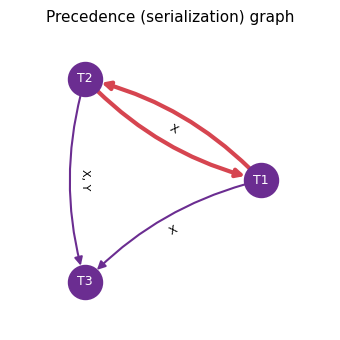

Step 5 — Conclusion
Result: NOT CONFLICT SERIALIZABLE
The precedence graph has a cycle: T1 -> T2 -> T1


In [6]:
_ = analyze_schedule("W2(x), W1(x), R3(x), R1(x), W2(y), R3(y), R3(z), R2(x)")

## Try other examples

Step 1 — Input schedule
S = R1(A) W1(A) R2(A) W2(A) R1(B) W1(B) R2(B) W2(B)

Step 2 — Schedule table


,T1,T2
0,R1(A),
1,W1(A),
2,,R2(A)
3,,W2(A)
4,R1(B),
5,W1(B),
6,,R2(B)
7,,W2(B)



Step 3 — Conflicting pairs -> precedence edges
  T1 -> T2   (A: R1(A) before W2(A))
  T1 -> T2   (B: R1(B) before W2(B))

Step 4 — Precedence (serialization) graph


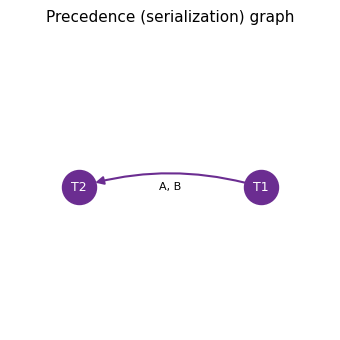

Step 5 — Conclusion
Result: CONFLICT SERIALIZABLE
The precedence graph has no cycle.
Equivalent serial order: T1 -> T2


In [7]:
_ = analyze_schedule("R1(A), W1(A), R2(A), W2(A), R1(B), W1(B), R2(B), W2(B)")  # serializable

Step 1 — Input schedule
S = R1(A) W2(A) R2(B) W1(B)

Step 2 — Schedule table


,T1,T2
0,R1(A),
1,,W2(A)
2,,R2(B)
3,W1(B),



Step 3 — Conflicting pairs -> precedence edges
  T1 -> T2   (A: R1(A) before W2(A))
  T2 -> T1   (B: R2(B) before W1(B))

Step 4 — Precedence (serialization) graph


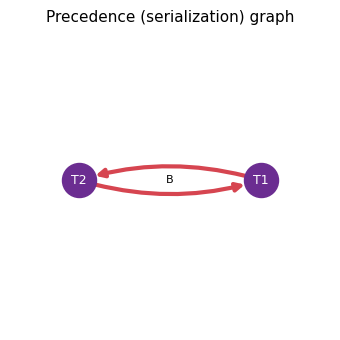

Step 5 — Conclusion
Result: NOT CONFLICT SERIALIZABLE
The precedence graph has a cycle: T1 -> T2 -> T1


In [8]:
_ = analyze_schedule("R1(A), W2(A), R2(B), W1(B)")  # cycle -> not serializable